In [ ]:
#Neural Network Algorithm. Word2Vec (Most Famous)
#1. CBOW (Continuous Bag of Words)
#Words with similar meaning end up close in vector space.
#Word2Vec learns this from word context.
!pip install gensim

In [17]:
from gensim.models import Word2Vec

sentences = [
    ["machine", "learning", "is", "fun"],
    ["deep", "learning", "is", "a", "subset", "of", "machine", "learning"],
    ["python", "is", "great", "for", "machine", "learning"],
    ["gensim", "implements", "word2vec"],
    ["word2vec", "creates", "word", "embeddings"]
]

from gensim.models import Word2Vec

model = Word2Vec(
    sentences,
    vector_size=100,
    window=5, #Context size
    min_count=1, #Ignore rare words. #Words appearing <1 times are removed.
    workers=4 #Parallel CPU threads.
)
vector = model.wv["machine"]
#print(vector)

In [18]:
#List all words learned:
print("------------------------")
print(model.wv.index_to_key)

print("------------------------")
print(model.wv.most_similar("learning"))
print("------------------------")
print(model.wv.similarity("machine", "learning"))

#vocabulary size
print("------------------------")
print(len(model.wv))

#save model
print("------------------------")
model.save("word2vec.model")

#load model
model = Word2Vec.load("word2vec.model")

------------------------
['learning', 'is', 'machine', 'word2vec', 'embeddings', 'word', 'creates', 'implements', 'gensim', 'for', 'great', 'python', 'of', 'subset', 'a', 'deep', 'fun']
------------------------
[('fun', 0.21883946657180786), ('for', 0.21616436541080475), ('of', 0.09310111403465271), ('implements', 0.09291721880435944), ('python', 0.07961919158697128), ('great', 0.06285417824983597), ('deep', 0.054333679378032684), ('gensim', 0.027057476341724396), ('creates', 0.01611165702342987), ('is', -0.010839177295565605)]
------------------------
-0.052346732
------------------------
17
------------------------


In [ ]:
#load file
with open("data.txt") as f:
    text = f.read()

import re
#preprocess
text = text.lower()
text = re.sub("[^a-z ]", "", text)
sentences = [line.split() for line in text.split("\n") if line]

#train
model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

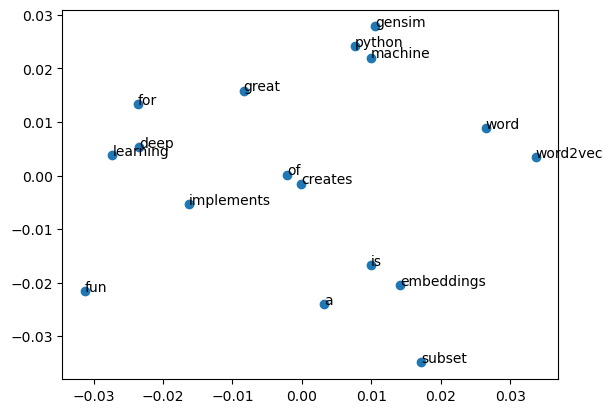

In [19]:
#Visualizing Word Embeddings : This shows words clustering by meaning.
#!pip install scikit-learn matplotlib
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model.wv.index_to_key)
vectors = model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.scatter(result[:,0], result[:,1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i,0], result[i,1]))

plt.show()